# Notebook 00 — Environment Check

**FIN 4600 · Lab 3 · Financial Data Analytics**

Run this notebook first. It does no finance — its only job is to prove that
your Python environment, your packages, and the data files are all working
before you invest time in the real labs.

**How to run a notebook cell:** click inside the cell and press
`Shift + Enter`. The `[ ]` to the left of the cell turns into `[*]` while it
runs and then into a number when it finishes.

If the very first cell fails, stop and go back to `SETUP.md`. Nothing further
in this course will work until it passes.

## 1. Which Python am I actually running?

This is the single most common source of confusion. Your computer may have
several Pythons installed. The one this notebook uses must be the one inside
the project's `.venv` folder, which is the environment `uv sync` built.

In [1]:
import sys
from pathlib import Path

print("Python executable:")
print("   ", sys.executable)
print("Python version:", sys.version.split()[0])

if ".venv" in sys.executable:
    print("\nOK — you are running the project virtual environment.")
else:
    print(
        "\nWARNING — this does NOT look like the project's .venv.\n"
        "In VS Code, click 'Select Kernel' in the top-right of this notebook\n"
        "and choose the interpreter whose path contains '.venv'.\n"
        "See the troubleshooting section of SETUP.md."
    )

Python executable:
    /Users/sabrinaloftus/mtu4600-lab3-analytics/.venv/bin/python
Python version: 3.12.14

OK — you are running the project virtual environment.


## 2. Are the packages installed, and at what versions?

Recording versions matters more in finance than in most fields. If a risk
number cannot be reproduced, it cannot be audited — and a number that cannot
be audited is not a number a regulator will accept.

In [2]:
import numpy
import pandas
import matplotlib
import seaborn
import sklearn

for module in (numpy, pandas, matplotlib, seaborn, sklearn):
    print(f"{module.__name__:<14} {module.__version__}")

Matplotlib is building the font cache; this may take a moment.


numpy          2.5.3
pandas         3.0.5
matplotlib     3.11.2
seaborn        0.13.2
sklearn        1.9.1


## 3. Can I find the data?

Every notebook in this lab locates the repository by walking up the folder
tree until it finds `data/sp500_prices.csv`. That makes the notebooks work no
matter which folder VS Code happens to start them in.

In [3]:
def find_repo_root(start=None):
    """Return the repository root — the folder that contains data/sp500_prices.csv."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "sp500_prices.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. In VS Code use File > Open Folder "
        "and open the mtu4600-lab3-analytics folder itself, then re-run."
    )


REPO = find_repo_root()
DATA = REPO / "data"

print("Repository root:", REPO)
print("\nData files found:")
for csv in sorted(DATA.glob("*.csv")):
    size_kb = csv.stat().st_size / 1024
    print(f"   {csv.name:<24} {size_kb:8.1f} KB")

Repository root: /Users/sabrinaloftus/mtu4600-lab3-analytics

Data files found:
   german_credit.csv           225.5 KB
   sp500_companies.csv           9.8 KB
   sp500_prices.csv           1791.6 KB
   us10y_monthly.csv             6.8 KB
   vix_daily.csv                59.3 KB


## 4. Can I load the data and draw a chart?

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use(REPO / "fin4600.mplstyle")

prices = pd.read_csv(DATA / "sp500_prices.csv", parse_dates=["date"])
print("Loaded", f"{len(prices):,}", "rows of daily prices")
print("Date range:", prices["date"].min().date(), "to", prices["date"].max().date())
print("Tickers:", prices["ticker"].nunique())

prices.head()

Loaded 37,770 rows of daily prices
Date range: 2013-02-08 to 2018-02-07
Tickers: 30


,date,ticker,open,high,low,close,volume
0,2013-02-08,AAPL,67.7142,68.4014,66.8928,67.8542,158168416
1,2013-02-11,AAPL,68.0714,69.2771,67.6071,68.5614,129029425
2,2013-02-12,AAPL,68.5014,68.9114,66.8205,66.8428,151829363
3,2013-02-13,AAPL,66.7442,67.6628,66.1742,66.7156,118721995
4,2013-02-14,AAPL,66.3599,67.3771,66.2885,66.6556,88809154


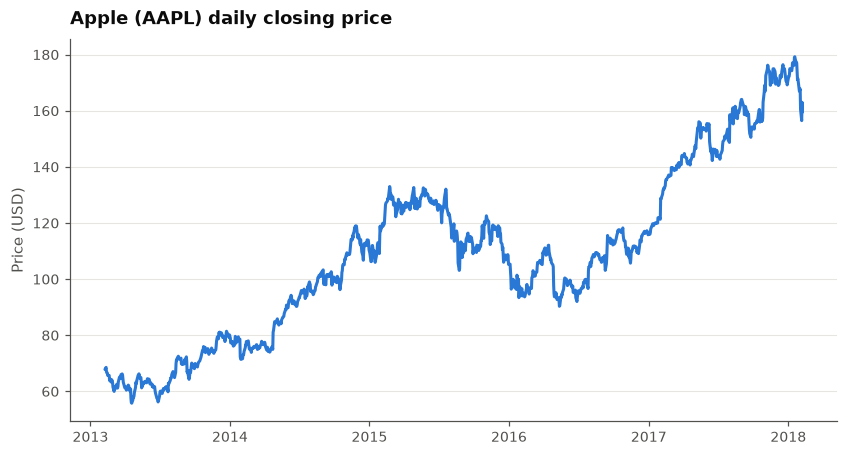

In [5]:
aapl = prices.loc[prices["ticker"] == "AAPL"].set_index("date")

fig, ax = plt.subplots()
ax.plot(aapl.index, aapl["close"])
ax.set_title("Apple (AAPL) daily closing price")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("")
plt.show()

## 5. Is scikit-learn working?

A throwaway model on made-up numbers — we only want to see that the library
imports, fits, and predicts.

In [6]:
import numpy as np
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(42)
X = rng.normal(size=(200, 3))
y = (X[:, 0] + 0.5 * X[:, 1] > 0).astype(int)

model = LogisticRegression().fit(X, y)
print("Training accuracy on synthetic data:", round(model.score(X, y), 3))

Training accuracy on synthetic data: 0.99


---

## If every cell above ran without an error, you are ready.

Move on to `01_pandas_fundamentals.ipynb`.

### Submitting this notebook

1. Save the notebook (`Ctrl/Cmd + S`).
2. In the VS Code **Source Control** panel, stage the change, write a commit
   message such as `Completed environment check`, and click **Commit**.
3. Click **Sync Changes** to push it to your own GitHub repository.